# ROM1 Base-Excitation Bifurcation Study

This notebook mirrors the Duffing stroboscopic bifurcation workflow using the electromechanical ROM1 model under base excitation.

Target plot: base acceleration amplitude vs stroboscopic tip displacement $x_{tip}(nT)$.

In [6]:
import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

try:
    from joblib import Parallel, delayed
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# Ensure workspace root containing Modeling/ is first on sys.path.
cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / 'Modeling').is_dir()), None)
if project_root is None:
    raise RuntimeError('Could not find project root containing Modeling/.')
sys.path.insert(0, str(project_root))

from Modeling.models.beam_properties import PiezoBeamParams
import Modeling.models.ROM1 as rom1_module
importlib.reload(rom1_module)
ROM = rom1_module.ROM

print(f'Project root: {project_root}')
print(f'Joblib available: {HAS_JOBLIB}')

Project root: C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam
Joblib available: True


In [7]:
# =========================
# ROM1 parameters
# =========================
L_b = 55e-3

params_rom = PiezoBeamParams(
    rho_p=7600,
    rho_s=8500,
    s11=14.5e-12,
    E_s=100e9,
    d31=-19.5e-11,
    eps_r=1700,
    b=31.75e-3,
    hp=0.275e-3,
    hs=0.128e-3,
    n_patches=1,
    w_p=L_b,
    omega_p=110 * 2 * np.pi,
    omega_q=200 * 2 * np.pi,
)
params_rom.L_b = L_b
params_rom.xL = np.array([0.0])
params_rom.xR = np.array([L_b])

N_modes = 1
rom = ROM(params=params_rom, N=N_modes, modal_damping_ratios=np.array([0.0065] * N_modes))

print('First natural frequency [Hz]:', rom.omega[0] / (2 * np.pi))
print('Electromechanical coupling:', (rom.p.theta_mech * rom.Gamma)[0, 0])
print('Cp_scalar [nF]:', rom.p.Cp_scalar * 1e9)

First natural frequency [Hz]: 108.0311658833999
Electromechanical coupling: 0.08980169717447302
Cp_scalar [nF]: 157.85320482758618


In [8]:
# =========================
# Study settings (analogous to chaos_in_hardening)
# =========================
freq_hz = 110.0
omega_exc = 2 * np.pi * freq_hz
T = 2 * np.pi / omega_exc

n_periods_total = 2000
n_periods_keep = 200
points_per_period = 200
dt = T / points_per_period

a_base_values = np.linspace(0.05, 5.0, 120)

R_c = 1e4
K_p = 0.015
K_i = 278
K_c = 1e7
negative_capacitance_ratio = 0.0

rtol = 1e-7
atol = 1e-9

phi_tip = np.array([rom.mode_shape(r, rom.p.L_b) for r in range(rom.N)]).reshape(-1)

print('Tip reconstruction vector shape:', phi_tip.shape)
print('Sweep points:', len(a_base_values))

Tip reconstruction vector shape: (1,)
Sweep points: 120


In [9]:
def make_fe3_rhs(ode_sys):
    """Convert FE3 second-order form to first-order for solve_ivp."""
    n = ode_sys.M.shape[0]

    def rhs(t, y):
        x = y[:n]
        x_dot = y[n:]
        x_ddot = np.linalg.solve(ode_sys.M, ode_sys.f_ext(t) - ode_sys.C @ x_dot - ode_sys.f_int(x))
        return np.concatenate([x_dot, x_ddot])

    return rhs


def simulate_single_amplitude(a_amp):
    a_base = lambda t, A=a_amp: A * np.cos(omega_exc * t)

    ode_sys = rom.build_ode_system_base_excitation(
        a_base=a_base,
        j_exc=None,
        R_c=R_c,
        K_p=K_p,
        K_i=K_i,
        K_c=K_c,
        negative_capacitance_ratio=negative_capacitance_ratio,
        base_accel_amp=a_amp,
        freq_domain_amps=None,
    )

    n = ode_sys.M.shape[0]
    rhs = make_fe3_rhs(ode_sys)

    t_end = n_periods_total * T
    t_eval = np.arange(0.0, t_end, dt)
    y0 = np.zeros(2 * n)

    sol = solve_ivp(
        rhs,
        (0.0, t_end),
        y0=y0,
        t_eval=t_eval,
        method='RK45',
        rtol=rtol,
        atol=atol,
    )

    if not sol.success:
        return np.array([]), np.array([])

    # Mechanical modal coordinates are the first rom.N entries of x(t).
    eta = sol.y[:rom.N, :]
    x_tip = phi_tip @ eta

    strobe_mask = np.isclose(np.mod(sol.t, T), 0.0, atol=dt / 2)
    x_strobe = x_tip[strobe_mask]

    if x_strobe.size == 0:
        return np.array([]), np.array([])

    x_ss = x_strobe[-min(n_periods_keep, x_strobe.size):]
    return a_amp * np.ones_like(x_ss), x_ss


if HAS_JOBLIB:
    results = Parallel(n_jobs=-1, verbose=12)(
        delayed(simulate_single_amplitude)(a) for a in a_base_values
    )
else:
    results = [simulate_single_amplitude(a) for a in a_base_values]

valid_results = [r for r in results if r[0].size > 0]
if not valid_results:
    raise RuntimeError('No successful simulations. Try reducing amplitude range or loosening tolerances.')

a_all = np.concatenate([r[0] for r in valid_results])
x_tip_all = np.concatenate([r[1] for r in valid_results])

print(f'Valid sweep points: {len(valid_results)}/{len(a_base_values)}')
print(f'Total plotted points: {x_tip_all.size}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:  6.7min
[Parallel(n_jobs=-1)]: Done 102 out of 120 | elapsed:  8.3min remaining:  1.5min
[Parallel(n_jobs=-1)]: Done 115 out of 120 | elapsed:  9.3min remaining:   24.2s


Valid sweep points: 120/120
Total plotted points: 24000


[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:  9.4min finished


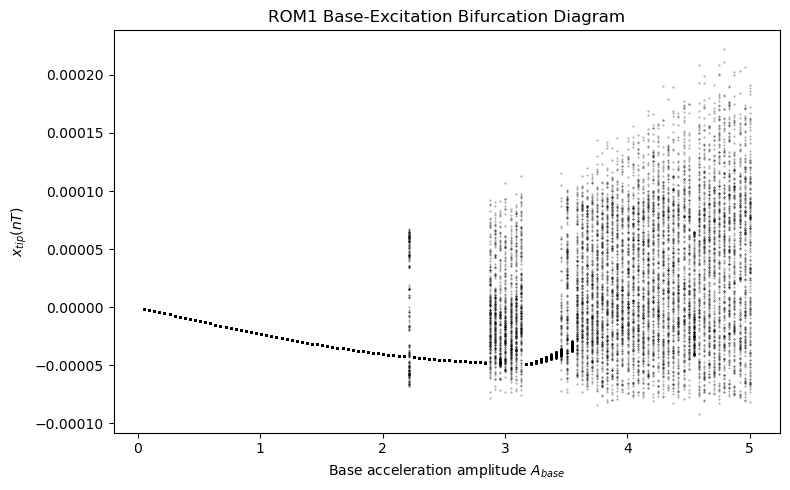

In [10]:
# =========================
# Bifurcation plot
# =========================
plt.figure(figsize=(8, 5))
plt.plot(a_all, x_tip_all, '.k', alpha=0.5, markersize=0.7)
plt.xlabel(r'Base acceleration amplitude $A_{base}$')
plt.ylabel(r'$x_{tip}(nT)$')
plt.title('ROM1 Base-Excitation Bifurcation Diagram')
plt.tight_layout()
plt.show()